IMPORT VÀ CẤU HÌNH

In [1]:
# NOTEBOOK 3: CNN MODEL - STATIC RECOGNITION

import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import json
from tqdm import tqdm
import warnings
import gc
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight
import seaborn as sns

# Dọn dẹp memory trước khi bắt đầu
torch.cuda.empty_cache()
gc.collect()

# Set environment variable để giảm memory fragmentation
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"GPU Memory at start: {torch.cuda.memory_allocated()/1024**2:.2f} MB")

Using device: cuda
GPU Memory at start: 0.00 MB


In [2]:
# Cấu hình
BONE_DATA_DIR = "/kaggle/input/notebooks/tonirighthere/notebook2/bone_data"
OUTPUT_DIR = "/kaggle/working/cnn_model"

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(f"{OUTPUT_DIR}/checkpoints", exist_ok=True)
print("GIAI ĐOẠN 3: CNN MODEL - STATIC RECOGNITION")

GIAI ĐOẠN 3: CNN MODEL - STATIC RECOGNITION


1. KIỂM TRA DỮ LIỆU

In [3]:
print("\n1. Kiểm tra dữ liệu...")

# Tìm đúng đường dẫn
if not os.path.exists(f"{BONE_DATA_DIR}/bone_metadata.json"):
    BONE_DATA_DIR = "/kaggle/input/bone_data"
    
bone_metadata_path = f"{BONE_DATA_DIR}/bone_metadata.json"
if not os.path.exists(bone_metadata_path):
    print("ERROR: Không tìm thấy bone_metadata.json!")
    print(f"Looking in: {BONE_DATA_DIR}")
    !ls -la {BONE_DATA_DIR} 2>/dev/null || echo "Directory not found"
    raise FileNotFoundError("Missing bone_metadata.json")

with open(bone_metadata_path, 'r') as f:
    metadata = json.load(f)

IMG_SIZE = metadata['img_size']
NUM_CLASSES = metadata['num_classes']
class_mapping = metadata['class_mapping']
# idx_to_class có thể có key là string hoặc int
if 'idx_to_class' in metadata:
    idx_to_class = metadata['idx_to_class']
else:
    idx_to_class = {str(v): k for k, v in class_mapping.items()}

print(f"Image size: {IMG_SIZE}x{IMG_SIZE}")
print(f"Number of classes: {NUM_CLASSES}")
print(f"Class mapping sample: {dict(list(class_mapping.items())[:5])}")


1. Kiểm tra dữ liệu...
Image size: 224x224
Number of classes: 29
Class mapping sample: {'0': 'A', '1': 'B', '2': 'C', '3': 'D', '4': 'E'}


2. DATASET CLASS

In [4]:
class BoneDiagramDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        img = cv2.imread(self.image_paths[idx])
        if img is None:
            img = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
        
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        if self.transform:
            img = self.transform(img)
        
        return img, self.labels[idx]

3. LOAD DATA

In [5]:
print("\n2. Loading bone diagrams...")

bone_images_dir = f"{BONE_DATA_DIR}/bone_images"
if not os.path.exists(bone_images_dir):
    bone_images_dir = "/kaggle/input/bone_data/bone_images"

image_paths = []
labels = []

# Class ID cần bỏ qua (nothing class)
CLASS_ID_TO_SKIP = 27  # nothing class

# Tự động sửa lỗi class_mapping bị ngược (nếu có)
fixed_mapping = {}
for k, v in class_mapping.items():
    if isinstance(v, str): 
        fixed_mapping[v] = int(k)  # Lật {"0": "A"} thành {"A": 0}
    else:
        fixed_mapping[k] = v       # Đã đúng {"A": 0} thì giữ nguyên
class_mapping = fixed_mapping

for class_name in os.listdir(bone_images_dir):
    class_dir = os.path.join(bone_images_dir, class_name)
    if os.path.isdir(class_dir) and class_name in class_mapping:
        current_label = class_mapping[class_name]
        
        # Bỏ qua class nothing (ID 27) vì quá ít samples
        if current_label == CLASS_ID_TO_SKIP:
            print(f"Skipping class '{class_name}' (ID: {CLASS_ID_TO_SKIP})")
            continue
            
        for img_name in os.listdir(class_dir):
            if img_name.endswith(('.png', '.jpg', '.jpeg')):
                image_paths.append(os.path.join(class_dir, img_name))
                labels.append(current_label)

print(f"Total samples loaded: {len(image_paths)}")

if len(image_paths) == 0:
    print("ERROR: Không có ảnh nào được load!")
    print(f"Bone images directory: {bone_images_dir}")
    print("Contents:", os.listdir(bone_images_dir) if os.path.exists(bone_images_dir) else "Directory not found")
    raise Exception("No data loaded")

# Kiểm tra phân phối
from collections import Counter
label_counts = Counter(labels)
print(f"Number of unique labels: {len(label_counts)}")
print(f"Min samples per class: {min(label_counts.values())}")
print(f"Max samples per class: {max(label_counts.values())}")


2. Loading bone diagrams...
Total samples loaded: 10857
Number of unique labels: 28
Min samples per class: 227
Max samples per class: 483


4. SPLIT DATA

In [6]:
print("\n3. Splitting data...")

# Split 1: 70% train, 30% temp (có stratify)
try:
    X_train, X_temp, y_train, y_temp = train_test_split(
        image_paths, labels, 
        test_size=0.3, 
        stratify=labels,
        random_state=42
    )
    print("First split with stratify successful")
except ValueError as e:
    print(f"Stratify failed: {e}")
    print("Falling back to non-stratified split...")
    X_train, X_temp, y_train, y_temp = train_test_split(
        image_paths, labels, 
        test_size=0.3, 
        random_state=42
    )

print(f"   Train: {len(X_train)} samples")
print(f"   Temp: {len(X_temp)} samples")

# Split 2: chia temp thành val và test (50-50) - bỏ stratify
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, 
    test_size=0.5,
    random_state=42
)

print(f"\nFinal split:")
print(f"   Train: {len(X_train)} samples")
print(f"   Validation: {len(X_val)} samples")
print(f"   Test: {len(X_test)} samples")


3. Splitting data...
First split with stratify successful
   Train: 7599 samples
   Temp: 3258 samples

Final split:
   Train: 7599 samples
   Validation: 1629 samples
   Test: 1629 samples


5. DATA AUGMENTATION

In [7]:
print("\n4. Setting up transforms...")

train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomRotation(15),
    transforms.RandomAffine(0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

val_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)), # BẤT BUỘC có để đồng bộ lúc test
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

train_dataset = BoneDiagramDataset(X_train, y_train, train_transform)
val_dataset = BoneDiagramDataset(X_val, y_val, val_transform)
test_dataset = BoneDiagramDataset(X_test, y_test, val_transform)

# Giảm batch_size để tránh OOM
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"Batch size: {batch_size}")


4. Setting up transforms...
Batch size: 32


6. CNN MODEL

In [8]:
print("\n5. Building CNN model (lightweight version)...")

# Dọn dẹp memory trước khi tạo model
torch.cuda.empty_cache()
gc.collect()

class LightweightASL_CNN(nn.Module):
    def __init__(self, num_classes=29, img_size=224):
        super(LightweightASL_CNN, self).__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            
            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            
            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            
            # Block 4
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            # Global Average Pooling: Rất quan trọng để tránh Overfitting
            nn.AdaptiveAvgPool2d((1, 1)) 
        )
        
        self.classifier = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

model = LightweightASL_CNN(num_classes=NUM_CLASSES).to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {total_params:,}")


# Kiểm tra GPU memory sau khi tạo model
print(f"GPU memory after model: {torch.cuda.memory_allocated()/1024**2:.2f} MB")



5. Building CNN model (lightweight version)...
Model parameters: 620,477
GPU memory after model: 2.38 MB


7. LOSS, OPTIMIZER, SCHEDULER

In [9]:
print("\n6. Setting up training...")

# Tính class weights cho những class thực sự có mặt
unique_labels_in_train = np.unique(y_train)
weights_subset = compute_class_weight('balanced', classes=unique_labels_in_train, y=y_train)

# Tạo mảng weights đầy đủ
full_weights = np.ones(NUM_CLASSES, dtype=np.float32)
for i, label_id in enumerate(unique_labels_in_train):
    full_weights[label_id] = weights_subset[i]

# Class 27 (nothing) đã bị loại, gán weight = 0
if 27 not in unique_labels_in_train:
    full_weights[27] = 0.0

class_weights = torch.tensor(full_weights, dtype=torch.float).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)


6. Setting up training...


8. TRAINING FUNCTIONS

In [10]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in tqdm(loader, desc="Training"):
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        
        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    return running_loss / len(loader), 100. * correct / total

In [11]:
def validate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc="Validation"):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
    return running_loss / len(loader), 100. * correct / total

9. TRAINING LOOP

In [12]:
print("\n7. Starting training...")

num_epochs = 100
best_val_acc = 0.0
train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print("-" * 40)
    
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = validate(model, val_loader, criterion)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
    
    scheduler.step(val_loss)
    
    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), f"{OUTPUT_DIR}/checkpoints/best_cnn_model.pth")
        print(f"Saved best model (val_acc: {val_acc:.2f}%)")
    
    # Early stopping nếu đạt 95%
    if val_acc >= 95.0:
        print(f"Early stopping at epoch {epoch+1}")
        break



7. Starting training...

Epoch 1/100
----------------------------------------


Validation: 100%|██████████| 51/51 [00:07<00:00,  6.81it/s]


Train Loss: 2.9114, Train Acc: 18.12%
Val Loss: 2.3718, Val Acc: 42.23%
Saved best model (val_acc: 42.23%)

Epoch 2/100
----------------------------------------


Validation: 100%|██████████| 51/51 [00:03<00:00, 13.40it/s]


Train Loss: 2.2351, Train Acc: 44.10%
Val Loss: 1.9047, Val Acc: 54.76%
Saved best model (val_acc: 54.76%)

Epoch 3/100
----------------------------------------


...

Train Loss: 0.6959, Train Acc: 90.84%
Val Loss: 0.9846, Val Acc: 69.31%

Epoch 9/100
----------------------------------------


Validation: 100%|██████████| 51/51 [00:03<00:00, 13.88it/s]


Train Loss: 0.5849, Train Acc: 91.85%
Val Loss: 0.8038, Val Acc: 81.58%

Epoch 10/100
----------------------------------------


Validation: 100%|██████████| 51/51 [00:03<00:00, 13.78it/s]

Train Loss: 0.4983, Train Acc: 92.53%
Val Loss: 0.3293, Val Acc: 95.27%
Saved best model (val_acc: 95.27%)
Early stopping at epoch 10


10. PLOT TRAINING CURVES


8. Plotting training curves...


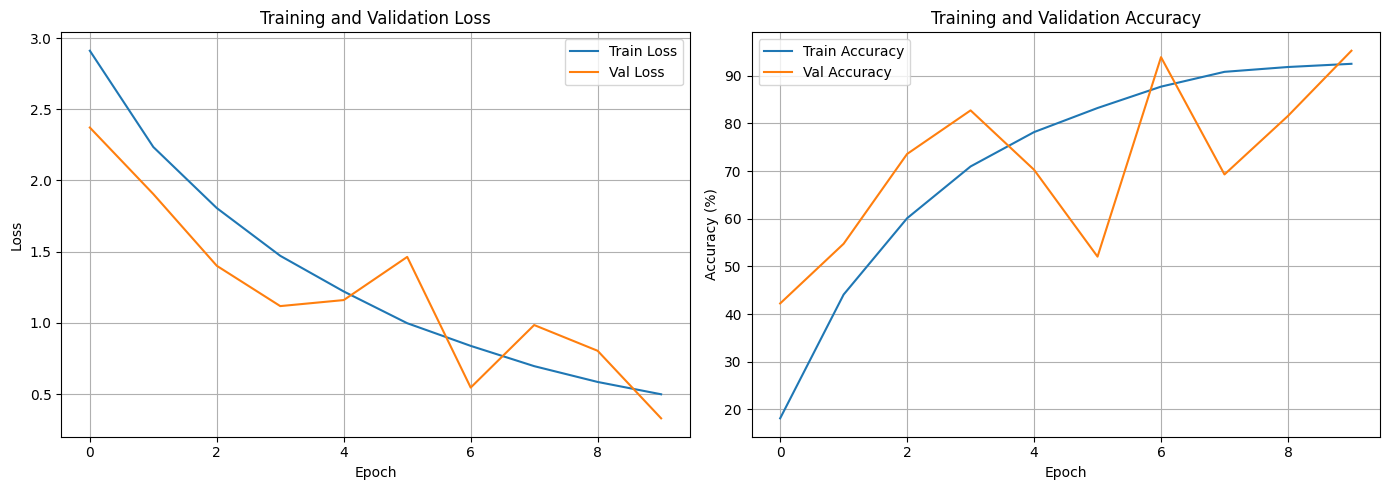

In [13]:
print("\n8. Plotting training curves...")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_losses, label='Train Loss')
axes[0].plot(val_losses, label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(train_accs, label='Train Accuracy')
axes[1].plot(val_accs, label='Val Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/training_curves.png")
plt.show()


11. EVALUATION ON TEST SET


9. Evaluating on test set...


Testing: 100%|██████████| 51/51 [00:06<00:00,  7.81it/s]



Test Accuracy: 95.33%

Classification Report:
              precision    recall  f1-score   support

     Class_0       1.00      0.98      0.99        58
     Class_1       1.00      1.00      1.00        52
     Class_2       1.00      0.96      0.98        50
     Class_3       0.95      0.97      0.96        60
     Class_4       1.00      0.98      0.99        64
     Class_5       0.96      0.99      0.98        81
     Class_6       0.94      0.99      0.96        69
     Class_7       0.98      1.00      0.99        51
     Class_8       0.93      0.85      0.89        62
     Class_9       0.90      0.91      0.90        57
    Class_10       1.00      1.00      1.00        67
    Class_11       0.82      0.98      0.90        65
    Class_12       0.87      0.72      0.79        36
    Class_13       0.85      0.88      0.86        32
    Class_14       0.98      0.97      0.98        62
    Class_15       0.97      1.00      0.98        58
    Class_16       1.00      0.98 

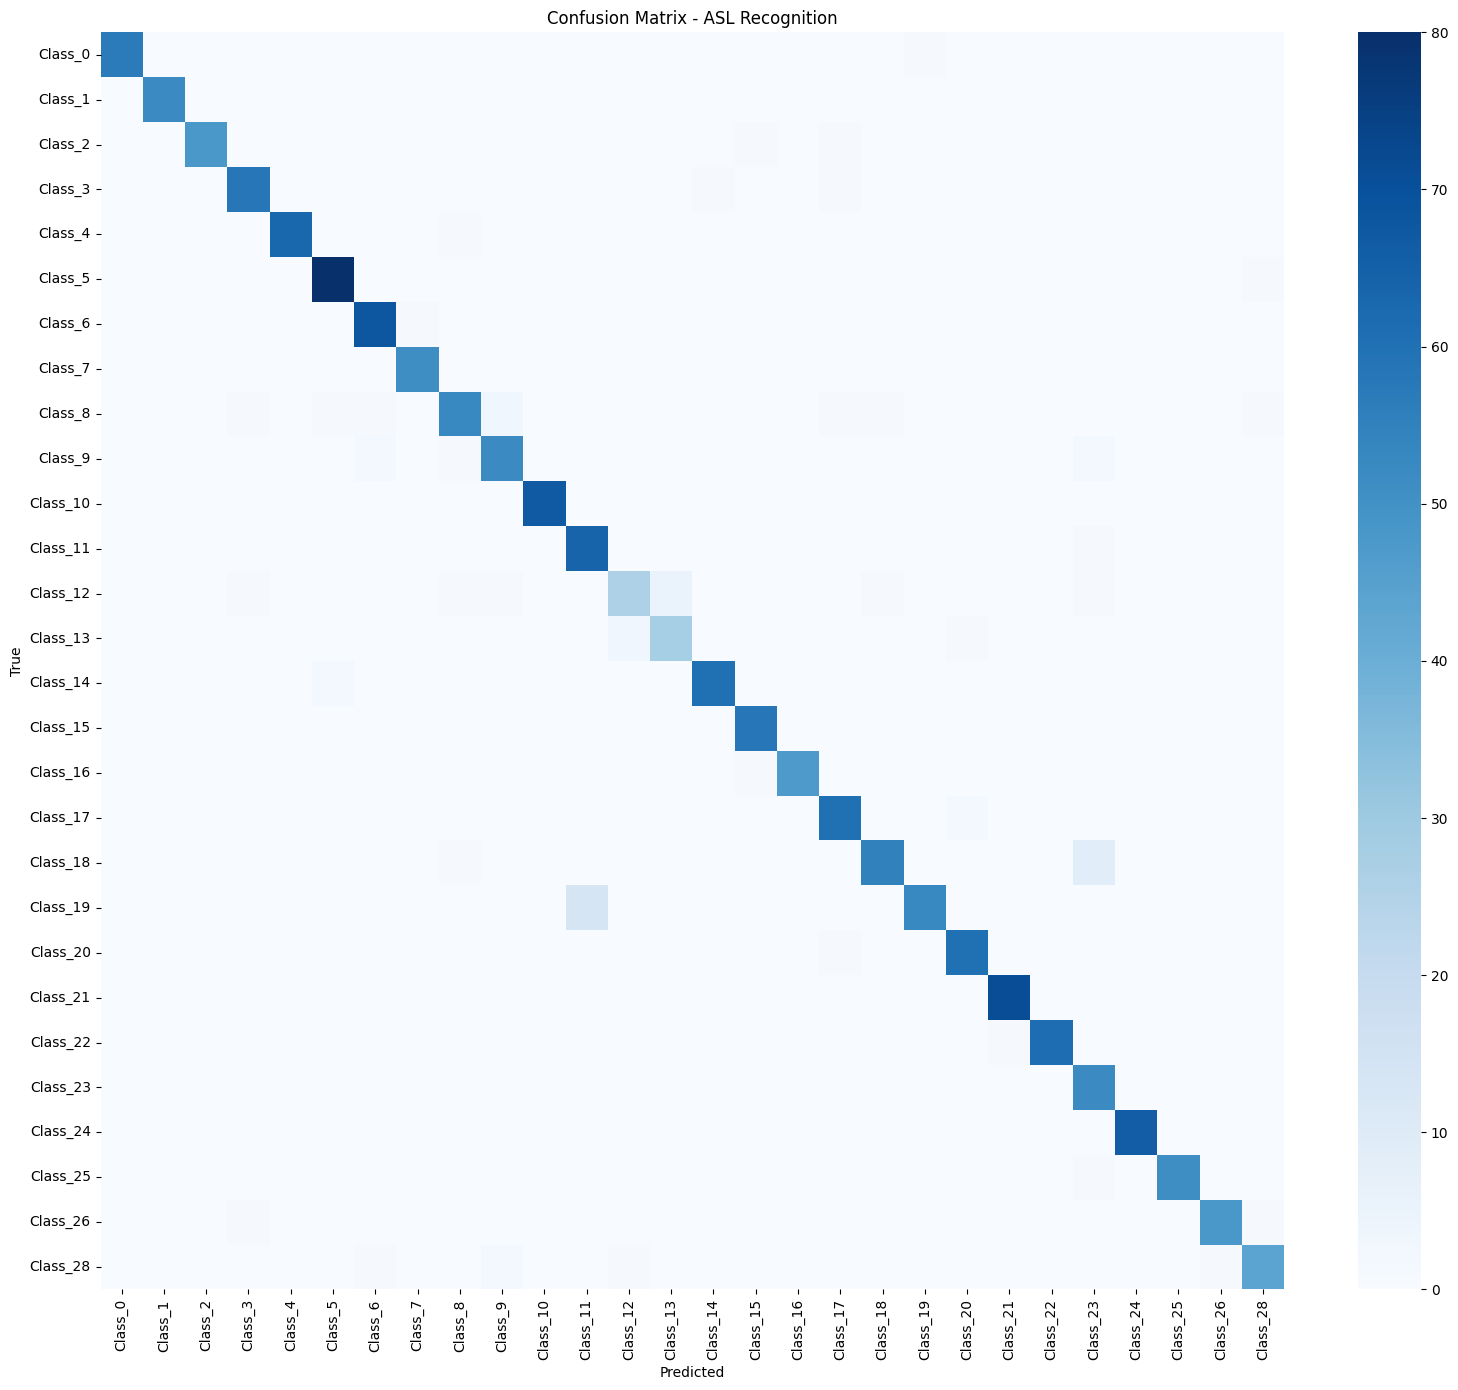

In [14]:
print("\n9. Evaluating on test set...")

# Load best model
model.load_state_dict(torch.load(f"{OUTPUT_DIR}/checkpoints/best_cnn_model.pth"))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="Testing"):
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

accuracy = accuracy_score(all_labels, all_preds)
print(f"\nTest Accuracy: {accuracy*100:.2f}%")

# Classification report
# Lấy danh sách class names (chỉ lấy các class có trong dữ liệu)
unique_classes_in_test = np.unique(all_labels)
class_names = [idx_to_class.get(str(i), f"Class_{i}") for i in range(NUM_CLASSES) if i in unique_classes_in_test]

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Confusion Matrix - ASL Recognition')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/confusion_matrix.png")
plt.show()

12. SAVE MODEL

In [15]:
print("\n10. Saving model...")

model_info = {
    'model_type': 'LightweightASL_CNN',
    'input_size': IMG_SIZE,
    'num_classes': NUM_CLASSES,
    'classes': [idx_to_class.get(str(i), f"Class_{i}") for i in range(NUM_CLASSES)],
    'test_accuracy': float(accuracy),
    'best_val_acc': float(best_val_acc),
    'total_parameters': total_params
}

with open(f"{OUTPUT_DIR}/model_info.json", 'w') as f:
    json.dump(model_info, f, indent=2)

# Save full model for deployment
torch.save({
    'model_state_dict': model.state_dict(),
    'class_mapping': class_mapping,
    'idx_to_class': idx_to_class,
    'img_size': IMG_SIZE,
    'model_info': model_info
}, f"{OUTPUT_DIR}/full_model.pth")

# Export to ONNX
try:
    dummy_input = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(device)
    torch.onnx.export(model, dummy_input, f"{OUTPUT_DIR}/asl_model.onnx",
                      input_names=['input'], output_names=['output'],
                      dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}})
    print("✓ Exported to ONNX format")
except Exception as e:
    print(f"ONNX export failed (optional): {e}")


10. Saving model...
ONNX export failed (optional): No module named 'onnxscript'


In [16]:
print("HOÀN THÀNH GIAI ĐOẠN 3!\n")
print(f"Best validation accuracy: {best_val_acc:.2f}%")
print(f"Test accuracy: {accuracy*100:.2f}%")
print(f"Total model parameters: {total_params:,}")
print(f"Model saved to: {OUTPUT_DIR}")
print("\nSave version và add /kaggle/working/cnn_model làm dataset output")

# Final memory cleanup
torch.cuda.empty_cache()
gc.collect()
print(f"Final GPU memory: {torch.cuda.memory_allocated()/1024**2:.2f} MB")

HOÀN THÀNH GIAI ĐOẠN 3!

Best validation accuracy: 95.27%
Test accuracy: 95.33%
Total model parameters: 620,477
Model saved to: /kaggle/working/cnn_model

Save version và add /kaggle/working/cnn_model làm dataset output
Final GPU memory: 43.98 MB


In [17]:
!zip -r /kaggle/working/model.zip /kaggle/working

  adding: kaggle/working/ (stored 0%)
  adding: kaggle/working/cnn_model/ (stored 0%)
  adding: kaggle/working/cnn_model/model_info.json (deflated 64%)
  adding: kaggle/working/cnn_model/checkpoints/ (stored 0%)
  adding: kaggle/working/cnn_model/checkpoints/best_cnn_model.pth (deflated 8%)
  adding: kaggle/working/cnn_model/training_curves.png (deflated 6%)
  adding: kaggle/working/cnn_model/confusion_matrix.png (deflated 32%)
  adding: kaggle/working/cnn_model/full_model.pth (deflated 8%)
  adding: kaggle/working/__notebook__.ipynb (deflated 76%)
